In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

## Hyperparameter Optimization

burlington-02
best: 0.0001 0.001


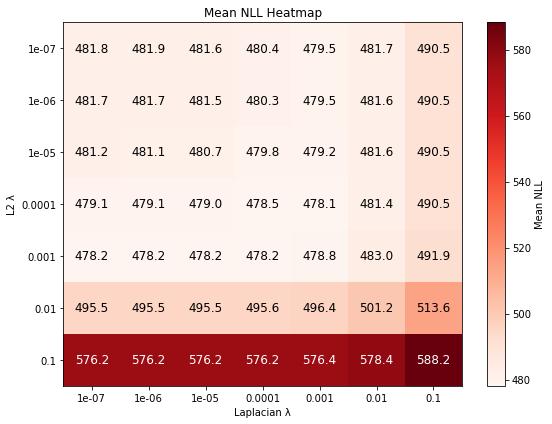

glasgow-04
best: 0.0001 0.001


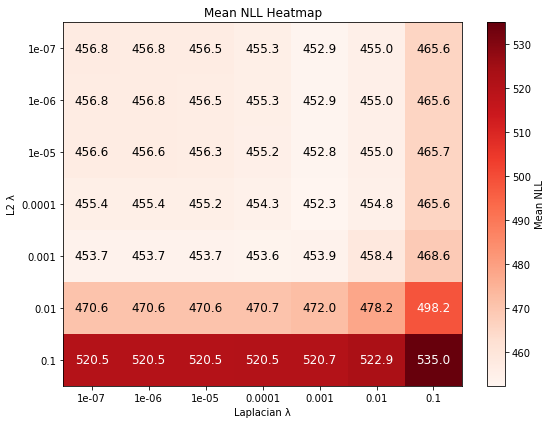

sf-11
best: 1e-07 1e-07


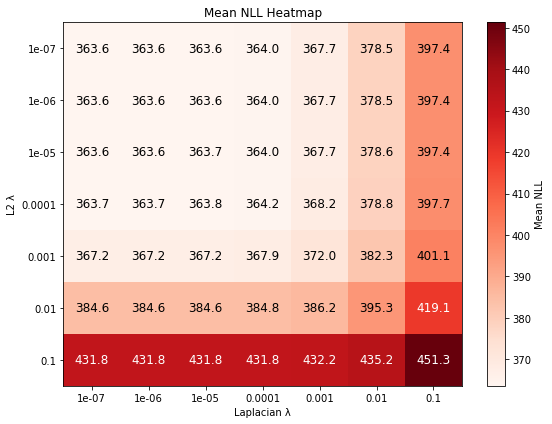

pierce-03
best: 1e-07 1e-07


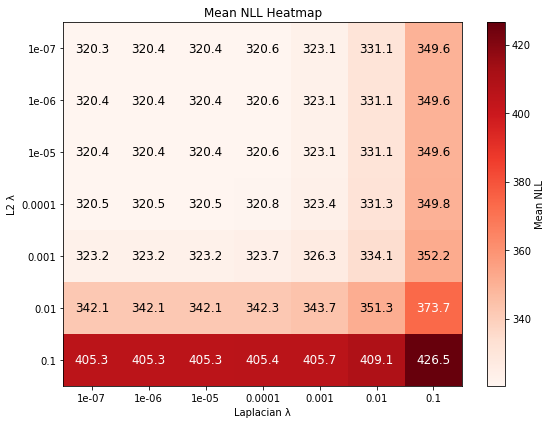

In [2]:
def get_optimal_lam(nlls, annotate=True, cmap="Reds"):
    """
    nlls: dict[l2_lam][laplacian_lam] -> list of NLLs
    """

    l2_lams = sorted(nlls.keys())
    lap_lams = sorted({lap for v in nlls.values() for lap in v})

    # matrix of mean NLLs
    nll_matrix = np.full((len(l2_lams), len(lap_lams)), np.nan)

    lowest_nll = np.inf
    best_l2_lam = None
    best_laplacian_lam = None

    for i, l2_lam in enumerate(l2_lams):
        for j, laplacian_lam in enumerate(lap_lams):
            if laplacian_lam not in nlls[l2_lam]:
                continue

            mean_nll = np.mean(nlls[l2_lam][laplacian_lam])
            nll_matrix[i, j] = mean_nll

            if mean_nll < lowest_nll:
                lowest_nll = mean_nll
                best_l2_lam = l2_lam
                best_laplacian_lam = laplacian_lam

    print("best:", best_l2_lam, best_laplacian_lam)

    # ---- Heatmap ----
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(nll_matrix, aspect="auto", cmap=cmap)

    ax.set_xticks(np.arange(len(lap_lams)))
    ax.set_yticks(np.arange(len(l2_lams)))
    ax.set_xticklabels(lap_lams)
    ax.set_yticklabels(l2_lams)

    ax.set_xlabel("Laplacian λ")
    ax.set_ylabel("L2 λ")
    ax.set_title("Mean NLL Heatmap")

    plt.colorbar(im, ax=ax, label="Mean NLL")

    if annotate:
        for i in range(len(l2_lams)):
            for j in range(len(lap_lams)):
                if not np.isnan(nll_matrix[i, j]):
                    ax.text(
                        j, i,
                        f"{nll_matrix[i, j]:.1f}",
                        ha="center", va="center",
                        color="white" if im.norm(nll_matrix[i, j]) > 0.5 else "black",
                        fontsize=12
                    )

    plt.tight_layout()
    plt.show()

    return best_l2_lam, best_laplacian_lam

for election_name in ["burlington-02", "glasgow-04", "sf-11", "pierce-03"]:
    filename = f"../results/hyperparam/push_pull/{election_name}.pickle"
    with open(filename, "rb") as file:
        nlls = pickle.load(file)
    print(election_name)
    get_optimal_lam(nlls)

## KL Divergence

```
Parameters: 
1 trial
poll is sampled with replacement
50 training steps
```

* glasgow: KL_by_election_ED-00008-00000002.soi.pickle
* key-elections: KL_by_election_ED-00023-00000001.toi.pickle
* sf: KL_by_election_ED-00021-00000010.toi.pickle

* Bootstrap results are in KL_by_election_key*

* note: irish election did not finish a single election. others that did not finish: glasgow-03-21, uklabor-01, sf-11-14

* decided that there is no good way to properly define KL divergence for boothstrap unless bootstrap has full support

* results using l2 are in l2_by_election and the corresponding distributions are in inferred_distribution_by_election

## Forecasting

* All win share results are in win_shares_by_election_key* (4 trials)

* ran 50 trials for burlington-02, sl-01, takomapark-01, sf-07. Each has its own pickle file.

In [2]:
exp_name = "sample_with_replacement"
election_names = ["burlington-02", "sf-11", "glasgow-04", "pierce-03"]
directory = Path("../results/push_pull_eval")

KL_results = {}
target_paths = [
    f"l2_by_election_{exp_name}_{election_name}.pickle" for election_name in election_names
]
for file_path in directory.glob("*.pickle"):
    if file_path.is_file() and file_path.name in target_paths:
        with file_path.open("rb") as f:
            results = pickle.load(f)
            
            for election_name in results:
                KL_results[election_name] = results[election_name]
# validate the results. confirm that the same number of trials completed for all sample sizes.
for election_name in KL_results:
    num_trials = -1
    for model_name in KL_results[election_name]:
        for sample_size in KL_results[election_name][model_name]:
            if num_trials == -1:
                num_trials = len(KL_results[election_name][model_name][sample_size])
            else:
                try:
                    assert len(KL_results[election_name][model_name][sample_size]) == num_trials
                except:
                    print(f"{model_name} {sample_size} {len(KL_results[election_name][model_name][sample_size])} {num_trials}")
    print(f"election: {election_name}\t {num_trials} trials")

Bootstrap 1000 20 100
Bootstrap 2000 20 100
Bootstrap 4000 20 100
PL 1000 20 100
PL 2000 20 100
PL 4000 20 100
PL + Rank 1000 20 100
PL + Rank 2000 20 100
PL + Rank 4000 20 100
PL + Context 1000 20 100
PL + Context 2000 20 100
PL + Context 4000 20 100
PL + Rank + Context 1000 20 100
PL + Rank + Context 2000 20 100
PL + Rank + Context 4000 20 100
PL + Rank + Context + Reg 1000 20 100
PL + Rank + Context + Reg 2000 20 100
PL + Rank + Context + Reg 4000 20 100
election: burlington-02	 100 trials
Bootstrap 1000 20 100
Bootstrap 2000 20 100
Bootstrap 4000 20 100
PL 1000 20 100
PL 2000 20 100
PL 4000 20 100
PL + Rank 1000 20 100
PL + Rank 2000 20 100
PL + Rank 4000 20 100
PL + Context 1000 20 100
PL + Context 2000 20 100
PL + Context 4000 20 100
PL + Rank + Context 1000 20 100
PL + Rank + Context 2000 20 100
PL + Rank + Context 4000 20 100
PL + Rank + Context + Reg 1000 20 100
PL + Rank + Context + Reg 2000 20 100
PL + Rank + Context + Reg 4000 20 100
election: glasgow-04	 100 trials
Bootstr

In [3]:
SMALL_SIZE = 18
MEDIUM_SIZE = 20
BIGGER_SIZE = 20
plt.rc('font', size=SMALL_SIZE, family = "Nimbus Roman")          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

colors = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a", "#66a61e"]
def get_color_from_model_name(model_name):
    model_to_color = {
        "Bootstrap": "black",
        "PL": colors[0],
        "PL + Rank": colors[1],
        "PL + Context": colors[2],
        "PL + Rank + Context": colors[3],
        "PL + Rank + Context + Reg": colors[4]
    }
    return model_to_color[model_name]

election_display_name = {
    "burlington-02": "Burlington 2009 Mayor",
    "glasgow-04": "Glasgow 2008 City Council - Canal Ward",
    "pierce-03": "Pierce County Executive 2008",
    "sf-11": "San Francisco Mayor 2011"
}

'NimbusRoman-Regular.otf' can not be subsetted into a Type 3 font. The entire font will be embedded in the output.


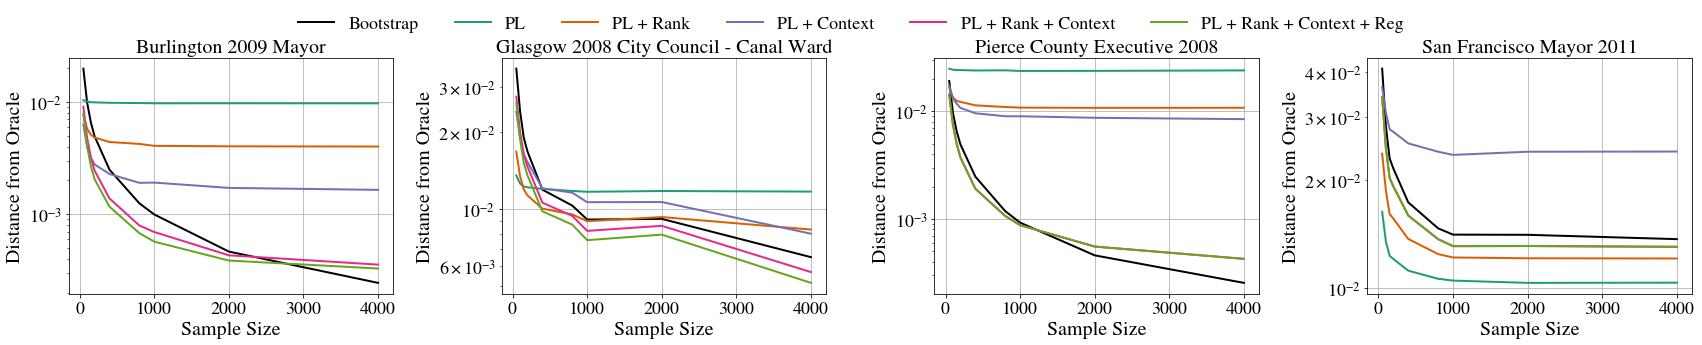

In [4]:
import math
import matplotlib.pyplot as plt
import numpy as np

model_names = [
    "Bootstrap",
    "PL",
    "PL + Rank",
    "PL + Context",
    "PL + Rank + Context",
    "PL + Rank + Context + Reg",
]

n_elections = len(KL_results)
n_cols = 4
n_rows = math.ceil(n_elections / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 5 * n_rows),
)

axes = axes.flatten()

for ax, election_name in zip(axes, KL_results):
    KL_by_sampling_rate = KL_results[election_name]

    ax.set_title(election_display_name[election_name])
    ax.set_xlabel("Sample Size")
    ax.set_ylabel("Distance from Oracle")
    ax.set_yscale("log")
    ax.grid(True)

    for model_name in model_names:
        sampling_rates = list(KL_by_sampling_rate[model_name].keys())
        kls = [
            np.mean(KL_by_sampling_rate[model_name][rate])
            for rate in sampling_rates
        ]

        ax.plot(
            sampling_rates,
            kls,
            color=get_color_from_model_name(model_name),
            linewidth=2,
            label=model_name,
        )

# Remove any unused subplots
for ax in axes[n_elections:]:
    ax.remove()

# ---- Single shared legend ----
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=6,
    frameon=False,
)


fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("../plots/profile_distance.pdf")

# Load Election Metadata

In [5]:
# map election_name to winner
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from irv import run_irv
import utils 

election_winners = {}
election_candidates = {}
for data_dir in ["key-elections", "key-1", "key-2"]:
    elections = utils.load_all_preflib_elections(election_dir=f"../data/preflib/{data_dir}")

    for collection, file_name, ballots, ballot_counts, cand_names, _ in elections:
        election_name = f"{collection}-{file_name[-6:-4]}"
        elim_votes = run_irv(len(cand_names),
            ballots.copy(),
            ballot_counts,
            cands=cand_names)
        winner = max(elim_votes, key=elim_votes.get)
        election_winners[election_name] = winner
        election_candidates[election_name] = list(cand_names.keys())
        
with open("../results/push_pull_eval/win_shares_by_election_oracle.pickle", "rb") as pickleFile:
    win_shares_oracle = pickle.load(pickleFile)
    
# unit test for oracle win shares
for election_name in win_shares_oracle:
    cands = election_candidates[election_name]
    for rate in win_shares_oracle[election_name]:
        win_shares = [win_shares_oracle[election_name][rate][cand] for cand in cands]
        assert abs(np.sum(win_shares) - 1.0) < 1e-6
print(win_shares_oracle.keys())
# election_winners

dict_keys(['sf-07', 'burlington-02', 'glasgow-04', 'pierce-03', 'sf-11'])


# Forecasting

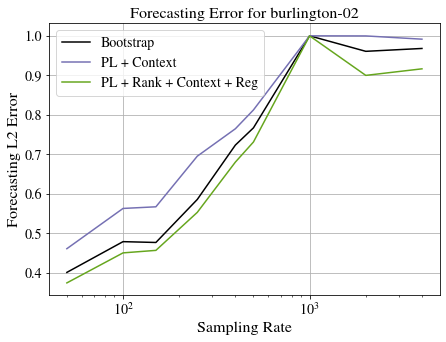

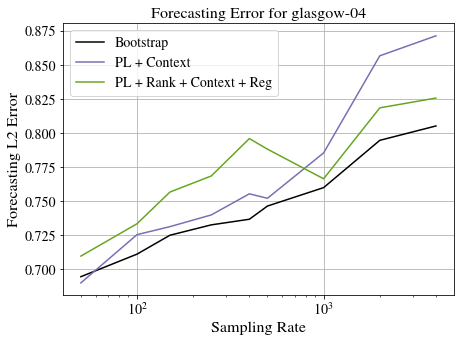

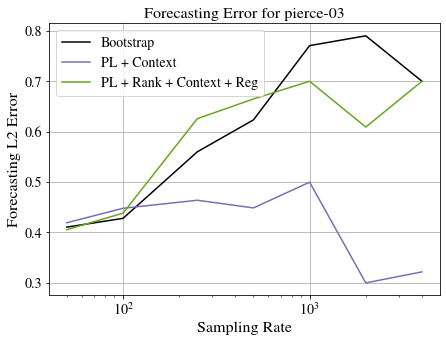

In [5]:
num_simulations = 250
for election_name in win_shares_results:        
 
    correct_winner = election_winners[election_name]
    cands = election_candidates[election_name]
    
    fig, ax = plt.subplots(figsize=(7,5))
    ax.set_title(f"Forecasting Error for {election_name}")
    ax.set_xlabel("Sampling Rate")
    ax.set_ylabel("Forecasting L2 Error")
    p_oracle = np.array([win_shares_oracle[election_name][1.0][cand] for cand in cands])
    
    for model_name in win_shares_results[election_name]:

        sample_sizes = [size for size in win_shares_results[election_name][model_name]]
        errors_by_size = []
        for size in sample_sizes:
            if size >= 1000:
                num_trials = 10
            elif election_name in ["pierce-03", "sf-11"]:
                num_trials = 75
            elif election_name in ["burlington-02", "glasgow-04"]:
                num_trials = 200
            
            errors = []
            for trial_idx in range(num_trials):
                # for num_simulations, sample n ballots to get a cand win shares vector
                cand_wins = {
                    cand: win_shares_results[election_name][model_name][size][cand][trial_idx]\
                    for cand in cands
                }
                
                # add error to errors
#                 error = cand_wins[correct_winner] / num_simulations
                p_estimated = np.array([cand_wins[cand] / num_simulations for cand in cands])
#                 error = np.linalg.norm(p_estimated - p_oracle)**2
                error = np.dot(p_oracle, p_estimated) / (np.linalg.norm(p_estimated) * np.linalg.norm(p_oracle))
                
                errors.append(error)
#             if model_name == "PL + Context":
#                 print([f"{x:.1e}" for x in errors])
            errors_by_size.append(np.mean(errors))
            
        ax.plot(sample_sizes, errors_by_size, 
                label=model_name, 
                color=get_color_from_model_name(model_name))
    ax.legend()
    ax.grid()
    ax.set_xscale("log")

oracle: {1: 0.9960000000000008, 2: 0, 3: 0, 4: 0, 5: 0.004, 6: 0}
Bootstrap
{1: 1.0}
{1: 0.508, 5: 0.492}
{1: 0.464, 5: 0.536}
{1: 0.016, 2: 0.984}
{1: 1.0}
{2: 1.0}
{2: 1.0}
{5: 1.0}
{1: 1.0}
{1: 1.0}
{2: 1.0}
PL + Context
{1: 0.932, 4: 0.068}
{1: 0.392, 5: 0.608}
{5: 1.0}
{2: 1.0}
{1: 1.0}
{2: 1.0}
{2: 1.0}
{5: 1.0}
{1: 1.0}
{1: 1.0}
{2: 1.0}
PL + Rank + Context + Reg
{1: 1.0}
{1: 0.048, 5: 0.952}
{1: 0.688, 5: 0.312}
{1: 0.028, 2: 0.972}
{1: 1.0}
{2: 1.0}
{2: 1.0}
{5: 1.0}
{1: 1.0}
{1: 1.0}
{2: 1.0}
Bootstrap
{1: 1.0}
{2: 1.0}
{1: 1.0}
{1: 1.0}
{2: 1.0}
{1: 0.912, 2: 0.088}
{1: 1.0}
{5: 1.0}
{5: 1.0}
{1: 0.992, 2: 0.008}
{1: 1.0}
PL + Context
{1: 1.0}
{2: 1.0}
{1: 1.0}
{1: 1.0}
{1: 1.0}
{1: 1.0}
{1: 1.0}
{1: 0.004, 5: 0.996}
{5: 1.0}
{1: 1.0}
{1: 1.0}
PL + Rank + Context + Reg
{1: 1.0}
{2: 1.0}
{1: 1.0}
{1: 0.996, 2: 0.004}
{2: 1.0}
{1: 0.252, 2: 0.748}
{1: 1.0}
{5: 1.0}
{5: 1.0}
{1: 0.928, 2: 0.072}
{1: 0.98, 4: 0.02}
Bootstrap
{1: 1.0}
{5: 1.0}
{1: 1.0}
{1: 0.232, 2: 0.768}
{1: 1.

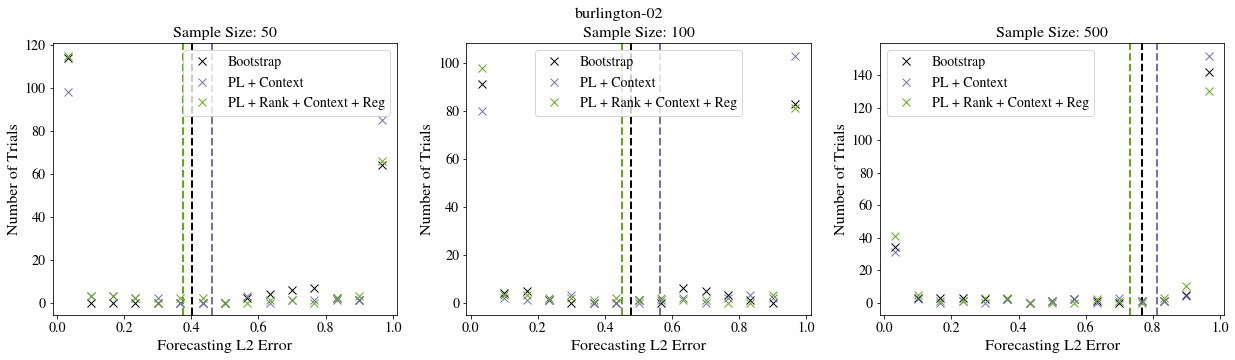

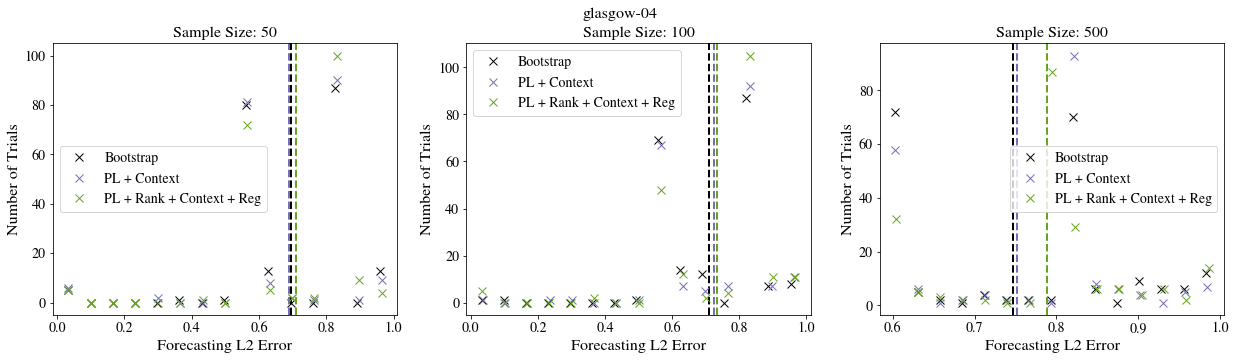

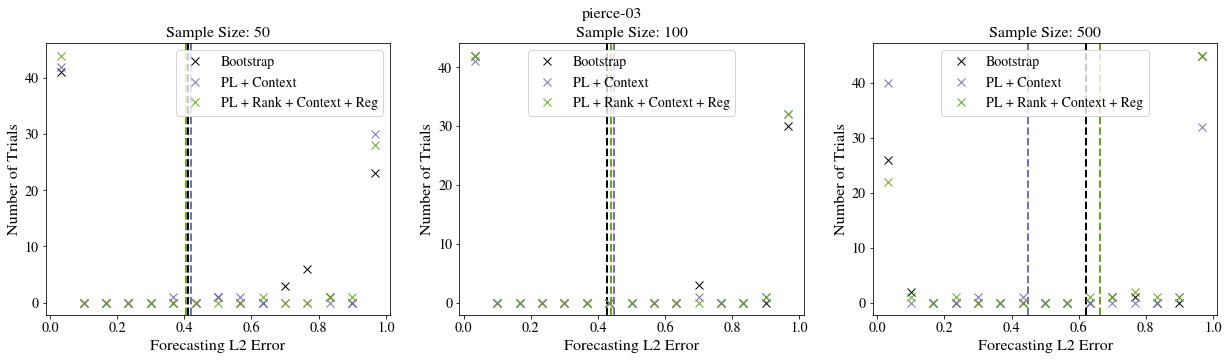

In [6]:
num_simulations = 250
bins = 15
sample_sizes = [50, 100, 500]

for election_name in win_shares_results:        
 
    correct_winner = election_winners[election_name]
    cands = election_candidates[election_name]
    oracle_vector = {cand: win_shares_oracle[election_name][1.0][cand] for cand in cands}
    print(f"oracle: {oracle_vector}")
    p_oracle = np.array([win_shares_oracle[election_name][1.0][cand] for cand in cands])

    # assumes sample size < 1000. For >= 1000, num_trials is 10
    if election_name in ["pierce-03", "sf-11"]:
        num_trials = 75
    elif election_name in ["burlington-02", "glasgow-04"]:
        num_trials = 200
                
    fig, axs = plt.subplots(figsize=(7 * len(sample_sizes), 5), ncols=len(sample_sizes))


    for ax_idx, size in enumerate(sample_sizes):
        axs[ax_idx].set_title(f"Sample Size: {size}")
        axs[ax_idx].set_xlabel("Forecasting L2 Error")
        axs[ax_idx].set_ylabel("Number of Trials")
                              
        for model_name in win_shares_results[election_name]:
            print(model_name)
            errors = []
            
            for trial_idx in range(num_trials):
                # for num_simulations, sample n ballots to get a cand win shares vector
                cand_wins = {
                    cand: win_shares_results[election_name][model_name][size][cand][trial_idx]\
                    for cand in cands
                }
                
                # add error to errors
#                 error = cand_wins[correct_winner] / num_simulations
                p_estimated = np.array([cand_wins[cand] / num_simulations for cand in cands])
#                 error = np.linalg.norm(p_estimated - p_oracle)**2
                error = np.dot(p_oracle, p_estimated) / (np.linalg.norm(p_estimated) * np.linalg.norm(p_oracle))
                
                if trial_idx <= 10:
                    print({cand: cand_wins[cand] / num_simulations for cand in cands if cand_wins[cand] > 0})
                errors.append(error)
                
            # Line histogram
            counts, bin_edges = np.histogram(errors, bins=bins, density=False)
            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

            # Plot points at bin centers
            axs[ax_idx].plot(
                bin_centers,
                counts,
                marker="x",
                linestyle="None",
                markersize=8,
                label=model_name,
                color=get_color_from_model_name(model_name),
            )

            # Mean line
            axs[ax_idx].axvline(
                np.mean(errors),
                linestyle="--",
                linewidth=2,
                color=get_color_from_model_name(model_name),
                alpha=1.0,
            )
        
        axs[ax_idx].legend()
    fig.suptitle(election_name)

burlington-02
Bootstrap [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Rank [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Context [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Rank + Context [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Rank + Context + Reg [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
glasgow-04
Bootstrap [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Rank [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Context [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Rank + Context [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Rank + Context + Reg [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
pierce-03
Bootstrap [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Rank [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Context [50, 100, 150, 200, 400, 800, 1000, 2000, 400

'NimbusRoman-Regular.otf' can not be subsetted into a Type 3 font. The entire font will be embedded in the output.
'NimbusRoman-Regular.otf' can not be subsetted into a Type 3 font. The entire font will be embedded in the output.
'NimbusRoman-Regular.otf' can not be subsetted into a Type 3 font. The entire font will be embedded in the output.


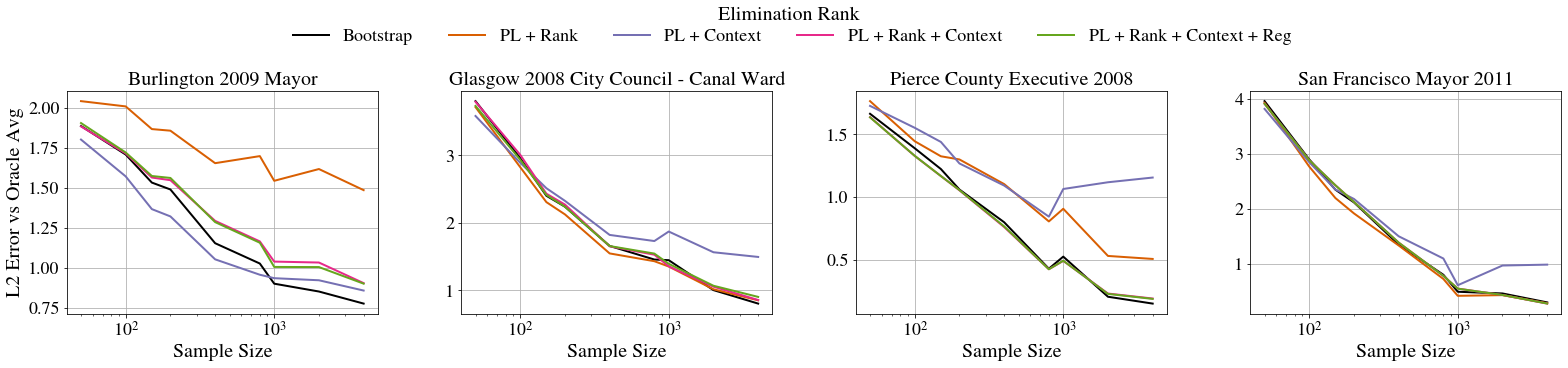

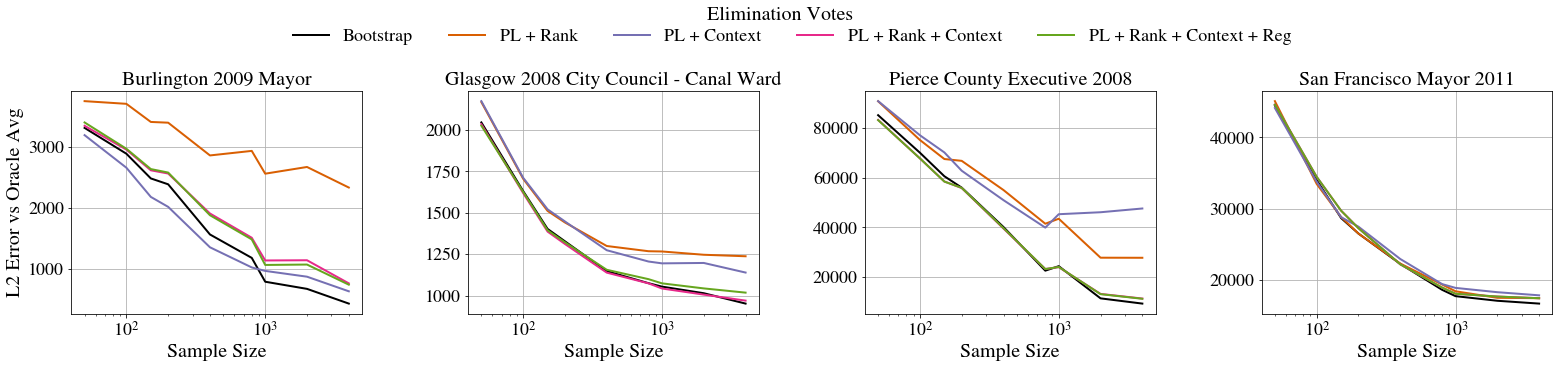

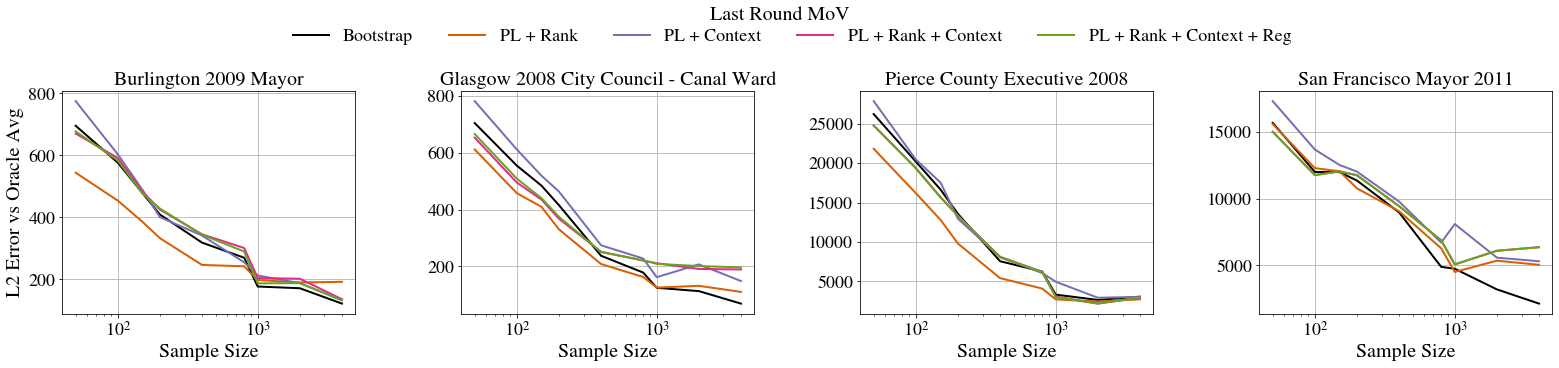

In [8]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# USER INPUT
# -------------------------
exp_name = "sample_with_replacement"

results_dir = "../results/push_pull_eval"
stat_names = ["elimination rank", "elimination votes", "last round mov"]

model_names = [
    "Bootstrap",
#     "PL",
    "PL + Rank",
    "PL + Context",
    "PL + Rank + Context",
    "PL + Rank + Context + Reg",
]

stat_display_name = {
    "elimination rank": "Elimination Rank",
    "elimination votes": "Elimination Votes",
    "last round mov": "Last Round MoV"
}



# You will provide this
max_k = 6  # <-- set this to what you want

# -------------------------
# HELPERS
# -------------------------
def load_pickle(path: str):
    with open(path, "rb") as f:
        return pickle.load(f)

def is_dictlike(x):
    return isinstance(x, dict)

def dict_to_vec(d, keys):
    return np.array([float(d[k]) for k in keys], dtype=np.float64)

def l2_error(trial_val, oracle_avg, dict_keys=None):
    if is_dictlike(oracle_avg):
        v_trial = dict_to_vec(trial_val, dict_keys)
        v_orc = dict_to_vec(oracle_avg, dict_keys)
        return float(np.linalg.norm(v_trial - v_orc, ord=2))
    else:
        return float(np.linalg.norm(np.array([float(trial_val) - float(oracle_avg)], dtype=np.float64), ord=2))

def compute_oracle_avg(oracle_stats, stat_name):
    vals = oracle_stats[stat_name]
    if len(vals) == 0:
        raise ValueError(f"Oracle has no trials for stat '{stat_name}'")

    if is_dictlike(vals[0]):
        key_set = set()
        for v in vals:
            key_set.update(v.keys())
        dict_keys = sorted(key_set, key=str)

        mat = np.stack([dict_to_vec(v, dict_keys) for v in vals], axis=0)
        avg_vec = mat.mean(axis=0)
        oracle_avg = {k: float(avg_vec[i]) for i, k in enumerate(dict_keys)}
        return oracle_avg, dict_keys
    else:
        return float(np.mean([float(v) for v in vals])), None

def patch_elimination_rank_dict_inplace(d: dict, oracle_keys, *, fill_value: float):
    """
    Temporary patch:
      - For elimination rank estimator dicts, add any missing candidates
        and set their value to (max_k + 1).
      - Also ensures no extra keys exist (optional: assert).
    """
    for k in oracle_keys:
        if k not in d:
            d[k] = fill_value

def assert_oracle_dicts_have_same_keys(election_name: str, stat_name: str, oracle_vals):
    oracle_keys = None
    for v in oracle_vals:
        if not is_dictlike(v):
            continue
        if oracle_keys is None:
            oracle_keys = set(v.keys())
        else:
            assert set(v.keys()) == oracle_keys, (
                f"[Oracle] Inconsistent keys in election='{election_name}', stat='{stat_name}'.\n"
                f"Expected: {sorted(oracle_keys)}\n"
                f"Found:    {sorted(v.keys())}"
            )
    return oracle_keys  # may be None if scalar stat

def assert_estimator_dicts_match_oracle_keys(
    election_name: str,
    stat_name: str,
    est_stats_by_model,
    oracle_keys,
):
    """
    For dict stats *other than* the patched case, enforce exact key match.
    """
    for model_name, by_sample_size in est_stats_by_model.items():
        for sample_size, stats_by_name in by_sample_size.items():
            vals = stats_by_name[stat_name]
            for v in vals:
                assert is_dictlike(v), (
                    f"[Estimator] Expected dict for election='{election_name}', "
                    f"stat='{stat_name}', model='{model_name}', sample_size={sample_size}"
                )
                if set(v.keys()) != oracle_keys:
                    missing = oracle_keys - set(v.keys())
                    extra = set(v.keys()) - oracle_keys
                    raise AssertionError(
                        f"[Estimator] Key mismatch in election='{election_name}', "
                        f"stat='{stat_name}', model='{model_name}', sample_size={sample_size}\n"
                        f"Missing keys: {sorted(missing)}\n"
                        f"Extra keys:   {sorted(extra)}"
                    )

def apply_elimination_rank_patch(
    election_name: str,
    est_stats_by_model,
    oracle_keys,
    *,
    fill_value: float,
):
    """
    Apply the temporary patch to estimator dicts for stat 'elimination rank' only.
    Mutates estimator values in-place.
    """
    for model_name, by_sample_size in est_stats_by_model.items():
        for sample_size, stats_by_name in by_sample_size.items():
            vals = stats_by_name["elimination rank"]
            for v in vals:
                assert is_dictlike(v), (
                    f"[Estimator] Expected dict for election='{election_name}', "
                    f"stat='elimination rank', model='{model_name}', sample_size={sample_size}"
                )
                patch_elimination_rank_dict_inplace(v, oracle_keys, fill_value=fill_value)

# -------------------------
# DISCOVER ELECTIONS FROM ORACLE FILES
# -------------------------
oracle_paths = sorted(glob.glob(os.path.join(results_dir, "oracle_forecast_*.pickle")))
if not oracle_paths:
    raise FileNotFoundError(f"No oracle files found at: {results_dir}/oracle_forecast_*.pickle")

elections = [
    os.path.basename(p).replace("oracle_forecast_", "").replace(".pickle", "")
    for p in oracle_paths
]

oracle_by_election = {e: load_pickle(p) for e, p in zip(elections, oracle_paths)}
for election_name in oracle_by_election:
    for elim_rank in oracle_by_election[election_name]["elimination rank"]:
        for cand in elim_rank:
            elim_rank[cand] = min(elim_rank[cand], max_k + 1)

estimator_by_election = {}
missing = []
for e in elections:
    est_path = os.path.join(results_dir, f"estimator_forecast_{exp_name}_{e}.pickle")
    if not os.path.exists(est_path):
        missing.append(est_path)
    else:
        estimator_by_election[e] = load_pickle(est_path)

for election_name in estimator_by_election:
    print(election_name)
    models = list(estimator_by_election[election_name].keys())
    for model in models:
        sample_sizes = list(estimator_by_election[election_name][model].keys())
        print(f"{model} {sample_sizes}")
if missing:
    raise FileNotFoundError(
        "Missing estimator forecast pickle(s).\n" + "\n".join(missing[:10])
        + ("" if len(missing) <= 10 else f"\n... and {len(missing) - 10} more")
    )

# -------------------------
# PLOTTING
# -------------------------
for stat_name in stat_names:
    n_elections = len(elections)
    fig, axes = plt.subplots(
        1, n_elections,
        figsize=(5.5 * n_elections, 4.8),
    )
    legend_handles = None
    legend_labels = None

    for j, election_name in enumerate(elections):
        ax = axes[j]
        ax.set_title(election_display_name[election_name])
        ax.set_xlabel("Sample Size")
        ax.set_xscale("log")
        if j == 0:
            ax.set_ylabel("L2 Error vs Oracle Avg")
        ax.grid(True)

        oracle_stats = oracle_by_election[election_name]
        est_stats_by_model = estimator_by_election[election_name]

        # ---- Key checks / patching ----
        oracle_vals = oracle_stats[stat_name]
        oracle_keys = assert_oracle_dicts_have_same_keys(election_name, stat_name, oracle_vals)

        if oracle_keys is not None:
            if stat_name == "elimination rank":
                # Temporary patch: fill missing candidates in estimator dicts
                apply_elimination_rank_patch(
                    election_name,
                    est_stats_by_model,
                    oracle_keys,
                    fill_value=max_k + 1,
                )
                # After patch, enforce that estimator keys now match oracle keys
                assert_estimator_dicts_match_oracle_keys(election_name, stat_name, est_stats_by_model, oracle_keys)
            else:
                # All other dict stats must match exactly
                assert_estimator_dicts_match_oracle_keys(election_name, stat_name, est_stats_by_model, oracle_keys)

        oracle_avg, dict_keys = compute_oracle_avg(oracle_stats, stat_name)

        for model_name in model_names:
            if model_name not in est_stats_by_model:
                continue

            sample_sizes = sorted(est_stats_by_model[model_name].keys())
            means = []
            stds = []

            for s in sample_sizes:
                trial_vals = est_stats_by_model[model_name][s][stat_name]
                if len(trial_vals) == 0:
                    means.append(np.nan)
                    stds.append(np.nan)
                    continue

                errs = np.array(
                    [l2_error(v, oracle_avg, dict_keys=dict_keys) for v in trial_vals],
                    dtype=np.float64
                )
                means.append(float(np.mean(errs)))
                stds.append(float(np.std(errs, ddof=0)))

            sample_sizes_arr = np.array(sample_sizes, dtype=np.float64)
            means_arr = np.array(means, dtype=np.float64)
            stds_arr = np.array(stds, dtype=np.float64)

            color = get_color_from_model_name(model_name)
            ax.plot(sample_sizes_arr, means_arr, linewidth=2, color=color, label=model_name)
            
#             print(f"{model_name} {means_arr}")
#             ax.fill_between(
#                 sample_sizes_arr,
#                 means_arr - stds_arr,
#                 means_arr + stds_arr,
#                 color=color,
#                 alpha=0.2,
#                 linewidth=0
#             )

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

    if legend_handles:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="upper center",
            ncol=min(6, len(legend_labels)),
            frameon=False,
            bbox_to_anchor=(0.5, 1.03)
        )

    fig.suptitle(f"{stat_display_name[stat_name]}", y=1.08)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(f"../plots/election_estimation_{stat_name}.pdf", bbox_inches="tight")
plt.show()


burlington-02
Bootstrap [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Rank [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Context [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Rank + Context [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Rank + Context + Reg [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
glasgow-04
Bootstrap [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Rank [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Context [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Rank + Context [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Rank + Context + Reg [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
pierce-03
Bootstrap [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Rank [50, 100, 150, 200, 400, 800, 1000, 2000, 4000]
PL + Context [50, 100, 150, 200, 400, 800, 1000, 2000, 400

'NimbusRoman-Regular.otf' can not be subsetted into a Type 3 font. The entire font will be embedded in the output.
'NimbusRoman-Regular.otf' can not be subsetted into a Type 3 font. The entire font will be embedded in the output.
'NimbusRoman-Regular.otf' can not be subsetted into a Type 3 font. The entire font will be embedded in the output.


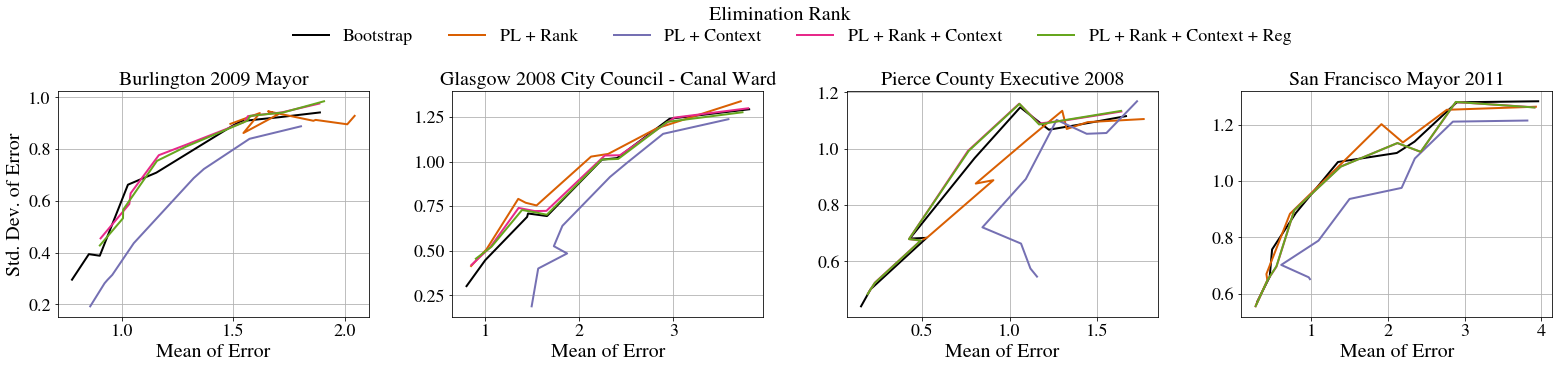

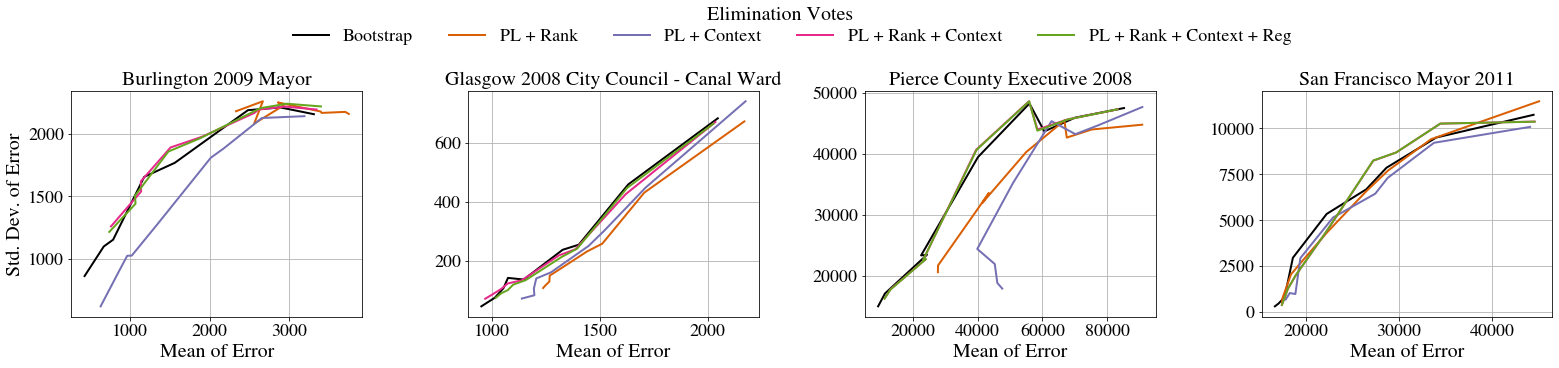

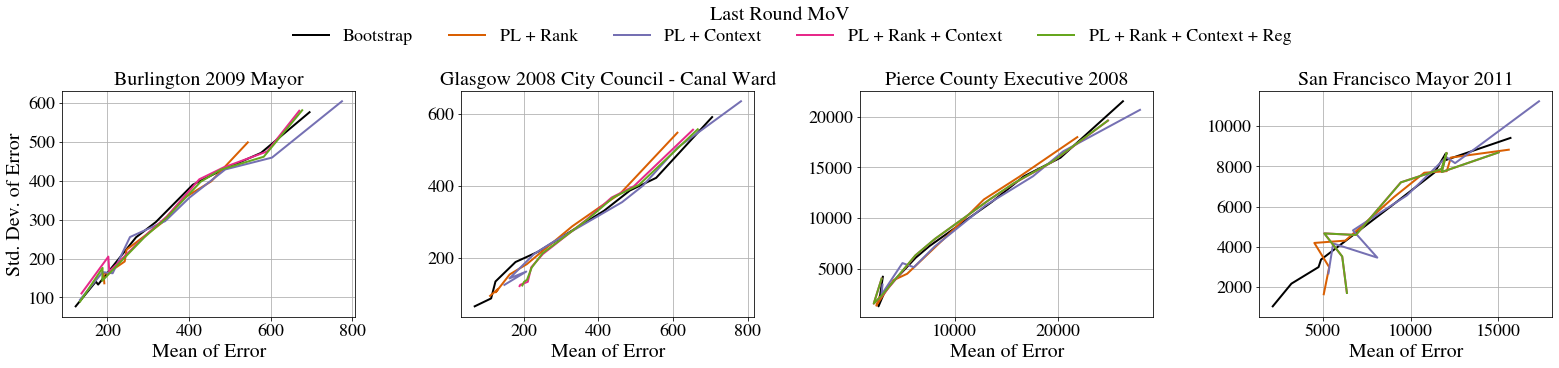

In [9]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# USER INPUT
# -------------------------
exp_name = "sample_with_replacement"

results_dir = "../results/push_pull_eval"
stat_names = ["elimination rank", "elimination votes", "last round mov"]

model_names = [
    "Bootstrap",
#     "PL",
    "PL + Rank",
    "PL + Context",
    "PL + Rank + Context",
    "PL + Rank + Context + Reg",
]

stat_display_name = {
    "elimination rank": "Elimination Rank",
    "elimination votes": "Elimination Votes",
    "last round mov": "Last Round MoV"
}

election_display_name = {
    "burlington-02": "Burlington 2009 Mayor",
    "glasgow-04": "Glasgow 2008 City Council - Canal Ward",
    "pierce-03": "Pierce County Executive 2008",
    "sf-11": "San Francisco Mayor 2011"
}

# You will provide this
max_k = 6  # <-- set this to what you want

# -------------------------
# HELPERS
# -------------------------
def load_pickle(path: str):
    with open(path, "rb") as f:
        return pickle.load(f)

def is_dictlike(x):
    return isinstance(x, dict)

def dict_to_vec(d, keys):
    return np.array([float(d[k]) for k in keys], dtype=np.float64)

def l2_error(trial_val, oracle_avg, dict_keys=None):
    if is_dictlike(oracle_avg):
        v_trial = dict_to_vec(trial_val, dict_keys)
        v_orc = dict_to_vec(oracle_avg, dict_keys)
        return float(np.linalg.norm(v_trial - v_orc, ord=2))
    else:
        return float(np.linalg.norm(np.array([float(trial_val) - float(oracle_avg)], dtype=np.float64), ord=2))

def compute_oracle_avg(oracle_stats, stat_name):
    vals = oracle_stats[stat_name]
    if len(vals) == 0:
        raise ValueError(f"Oracle has no trials for stat '{stat_name}'")

    if is_dictlike(vals[0]):
        key_set = set()
        for v in vals:
            key_set.update(v.keys())
        dict_keys = sorted(key_set, key=str)

        mat = np.stack([dict_to_vec(v, dict_keys) for v in vals], axis=0)
        avg_vec = mat.mean(axis=0)
        oracle_avg = {k: float(avg_vec[i]) for i, k in enumerate(dict_keys)}
        return oracle_avg, dict_keys
    else:
        return float(np.mean([float(v) for v in vals])), None

def patch_elimination_rank_dict_inplace(d: dict, oracle_keys, *, fill_value: float):
    """
    Temporary patch:
      - For elimination rank estimator dicts, add any missing candidates
        and set their value to (max_k + 1).
      - Also ensures no extra keys exist (optional: assert).
    """
    for k in oracle_keys:
        if k not in d:
            d[k] = fill_value

def assert_oracle_dicts_have_same_keys(election_name: str, stat_name: str, oracle_vals):
    oracle_keys = None
    for v in oracle_vals:
        if not is_dictlike(v):
            continue
        if oracle_keys is None:
            oracle_keys = set(v.keys())
        else:
            assert set(v.keys()) == oracle_keys, (
                f"[Oracle] Inconsistent keys in election='{election_name}', stat='{stat_name}'.\n"
                f"Expected: {sorted(oracle_keys)}\n"
                f"Found:    {sorted(v.keys())}"
            )
    return oracle_keys  # may be None if scalar stat

def assert_estimator_dicts_match_oracle_keys(
    election_name: str,
    stat_name: str,
    est_stats_by_model,
    oracle_keys,
):
    """
    For dict stats *other than* the patched case, enforce exact key match.
    """
    for model_name, by_sample_size in est_stats_by_model.items():
        for sample_size, stats_by_name in by_sample_size.items():
            vals = stats_by_name[stat_name]
            for v in vals:
                assert is_dictlike(v), (
                    f"[Estimator] Expected dict for election='{election_name}', "
                    f"stat='{stat_name}', model='{model_name}', sample_size={sample_size}"
                )
                if set(v.keys()) != oracle_keys:
                    missing = oracle_keys - set(v.keys())
                    extra = set(v.keys()) - oracle_keys
                    raise AssertionError(
                        f"[Estimator] Key mismatch in election='{election_name}', "
                        f"stat='{stat_name}', model='{model_name}', sample_size={sample_size}\n"
                        f"Missing keys: {sorted(missing)}\n"
                        f"Extra keys:   {sorted(extra)}"
                    )

def apply_elimination_rank_patch(
    election_name: str,
    est_stats_by_model,
    oracle_keys,
    *,
    fill_value: float,
):
    """
    Apply the temporary patch to estimator dicts for stat 'elimination rank' only.
    Mutates estimator values in-place.
    """
    for model_name, by_sample_size in est_stats_by_model.items():
        for sample_size, stats_by_name in by_sample_size.items():
            vals = stats_by_name["elimination rank"]
            for v in vals:
                assert is_dictlike(v), (
                    f"[Estimator] Expected dict for election='{election_name}', "
                    f"stat='elimination rank', model='{model_name}', sample_size={sample_size}"
                )
                patch_elimination_rank_dict_inplace(v, oracle_keys, fill_value=fill_value)

# -------------------------
# DISCOVER ELECTIONS FROM ORACLE FILES
# -------------------------
oracle_paths = sorted(glob.glob(os.path.join(results_dir, "oracle_forecast_*.pickle")))
if not oracle_paths:
    raise FileNotFoundError(f"No oracle files found at: {results_dir}/oracle_forecast_*.pickle")

elections = [
    os.path.basename(p).replace("oracle_forecast_", "").replace(".pickle", "")
    for p in oracle_paths
]

oracle_by_election = {e: load_pickle(p) for e, p in zip(elections, oracle_paths)}
for election_name in oracle_by_election:
    for elim_rank in oracle_by_election[election_name]["elimination rank"]:
        for cand in elim_rank:
            elim_rank[cand] = min(elim_rank[cand], max_k + 1)

estimator_by_election = {}
missing = []
for e in elections:
    est_path = os.path.join(results_dir, f"estimator_forecast_{exp_name}_{e}.pickle")
    if not os.path.exists(est_path):
        missing.append(est_path)
    else:
        estimator_by_election[e] = load_pickle(est_path)

for election_name in estimator_by_election:
    print(election_name)
    models = list(estimator_by_election[election_name].keys())
    for model in models:
        sample_sizes = list(estimator_by_election[election_name][model].keys())
        print(f"{model} {sample_sizes}")
if missing:
    raise FileNotFoundError(
        "Missing estimator forecast pickle(s).\n" + "\n".join(missing[:10])
        + ("" if len(missing) <= 10 else f"\n... and {len(missing) - 10} more")
    )

# -------------------------
# PLOTTING
# -------------------------
for stat_name in stat_names:
    n_elections = len(elections)
    fig, axes = plt.subplots(
        1, n_elections,
        figsize=(5.5 * n_elections, 4.8),
    )
    legend_handles = None
    legend_labels = None

    for j, election_name in enumerate(elections):
        ax = axes[j]
        ax.set_title(election_display_name[election_name])
        ax.set_xlabel("Mean of Error")
#         ax.set_xscale("log")
        if j == 0:
            ax.set_ylabel("Std. Dev. of Error")
        ax.grid(True)

        oracle_stats = oracle_by_election[election_name]
        est_stats_by_model = estimator_by_election[election_name]

        # ---- Key checks / patching ----
        oracle_vals = oracle_stats[stat_name]
        oracle_keys = assert_oracle_dicts_have_same_keys(election_name, stat_name, oracle_vals)

        if oracle_keys is not None:
            if stat_name == "elimination rank":
                # Temporary patch: fill missing candidates in estimator dicts
                apply_elimination_rank_patch(
                    election_name,
                    est_stats_by_model,
                    oracle_keys,
                    fill_value=max_k + 1,
                )
                # After patch, enforce that estimator keys now match oracle keys
                assert_estimator_dicts_match_oracle_keys(election_name, stat_name, est_stats_by_model, oracle_keys)
            else:
                # All other dict stats must match exactly
                assert_estimator_dicts_match_oracle_keys(election_name, stat_name, est_stats_by_model, oracle_keys)

        oracle_avg, dict_keys = compute_oracle_avg(oracle_stats, stat_name)

        for model_name in model_names:
            if model_name not in est_stats_by_model:
                continue

            sample_sizes = sorted(est_stats_by_model[model_name].keys())
            means = []
            stds = []

            for s in sample_sizes:
                trial_vals = est_stats_by_model[model_name][s][stat_name]
                if len(trial_vals) == 0:
                    means.append(np.nan)
                    stds.append(np.nan)
                    continue

                errs = np.array(
                    [l2_error(v, oracle_avg, dict_keys=dict_keys) for v in trial_vals],
                    dtype=np.float64
                )
                means.append(float(np.mean(errs)))
                stds.append(float(np.std(errs, ddof=0)))

            sample_sizes_arr = np.array(sample_sizes, dtype=np.float64)
            means_arr = np.array(means, dtype=np.float64)
            stds_arr = np.array(stds, dtype=np.float64)

            color = get_color_from_model_name(model_name)
            ax.plot(means_arr, stds_arr, linewidth=2, color=color, label=model_name)

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

    if legend_handles:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="upper center",
            ncol=min(6, len(legend_labels)),
            frameon=False,
            bbox_to_anchor=(0.5, 1.03)
        )

    fig.suptitle(f"{stat_display_name[stat_name]}", y=1.08)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(f"../plots/election_estimation_{stat_name}_pareto.pdf", bbox_inches="tight")
plt.show()
